In [46]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

In [47]:
from flonacomldft.models import MLP
from flonacomldft.data_utils import load_zmat_csv

In [48]:
def train(input, output, layer_dim, learning_rate, batchsize):
    
    model = MLP(layerdims=layers_dim)
    
    lr=learning_rate
    batch_size = batchsize
    
    loss_function = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr)

    losses = []
    for epoch in range(batch_size):
        y_predict = model(input)
        loss = loss_function(y_predict, output)
        losses.append(loss.item())

        model.zero_grad()
        loss.backward()

        optimizer.step()

    return model, losses

In [49]:
# These are the 12 internal coordinates + energy (50001 samples) Planar isomer
is1 = load_zmat_csv('is1')
is1 = is1[torch.randperm(is1.shape[0])]

n = 4000

x_train_ = is1[:, :-1][:n]
y_train_ = is1[:, -1][:n]
x_test_ = is1[:, :-1][n:]
y_test_ = is1[:, -1][n:]

In [50]:
def rescaling(data, dim):
    means = data.mean(dim=dim, keepdim=True)
    stds = data.std(dim=dim, keepdim=True)
    normalized_data = (data - means) / stds
    return normalized_data

def recovering(normalized_data, data, dim):
    data = (normalized_data.T*data.std(dim=dim) + data.mean(dim=dim)).T
    return data

In [51]:
x_train = rescaling(x_train_, 1)
y_train = rescaling(y_train_, 0).reshape(n, 1)
x_test = rescaling(x_test_, 1)
y_test = rescaling(y_test_, 0).reshape(1001, 1)

In [52]:
models = []
losses = []

for i in range(1, 15, 3):
    layers_dim = [12] + [50]*(i) + [1]
    lr = 0.005

    model_, losses_ = train(x_train, y_train, layers_dim, lr, 10000)
    models.append(model_)
    losses.append(losses_)

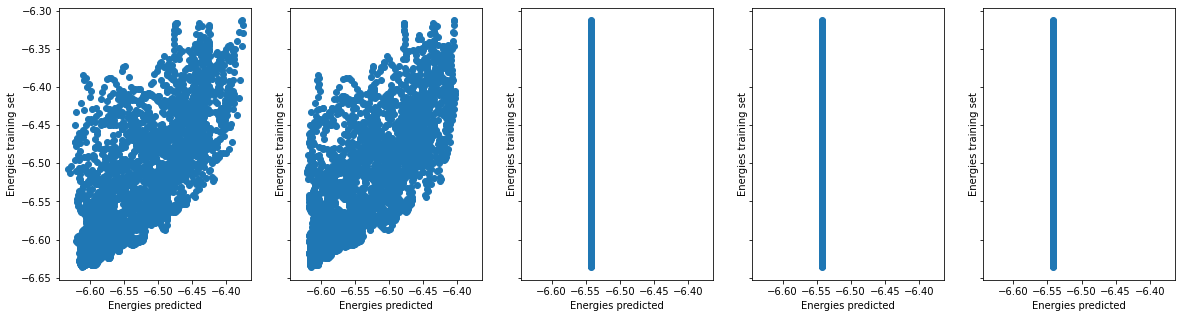

In [55]:
fig,axs = plt.subplots(1, len(models), figsize=(20, 5), sharey=True, sharex=True)

for ax, model in zip(axs, models):
    ax.scatter(recovering(model(x_train), y_train_, 0).detach().numpy(), recovering(y_train, y_train_, 0).detach().numpy())
    ax.set_xlabel('Energies predicted')
    ax.set_ylabel('Energies training set')
    

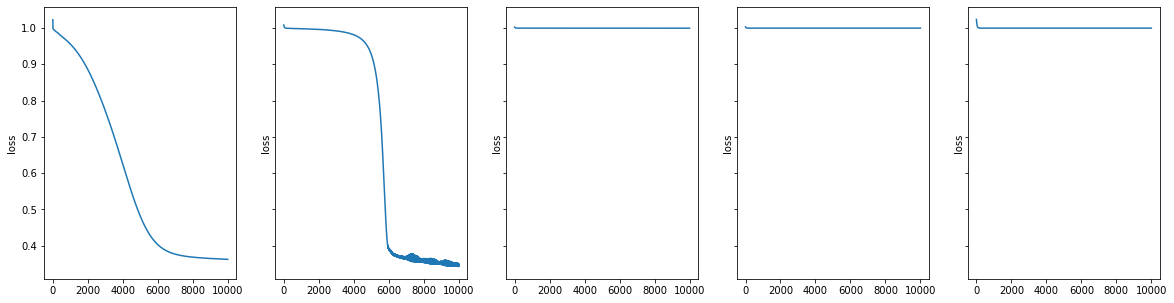

In [57]:
fig,axs = plt.subplots(1, len(losses), figsize=(20, 5), sharey=True, sharex=True)

for ax, loss in zip(axs, losses):
    ax.plot(loss)
    #ax.yscale('log')
    ax.set_ylabel('loss')